# Neuronové sítě

Na přednášce jste slyšeli úvod do další přírodou inspirované techniky - neuronových sítí. Mezi jejich nejjednodušší modely patří perceptron a vícevrstevný perceptron. Na cvičení si je tedy zkusíme sami naimplementovat.

***Důležitá poznámka:*** Níže importujeme *sklearn*. Budete-li pipem instalovat [*"sklearn"*](https://pypi.org/project/sklearn/), dost možná se vám to v nějaké formě povede nainstalovat, pravé jméno projektu / package je ale [*"scikit-learn"*](https://pypi.org/project/scikit-learn/), a tedy by měl být instalován následovně: `pip install scikit-learn`. *sklearn* je pouze jméno pro import. Je to matoucí? Jo. Ale já to nevymyslel...

In [29]:
import collections
import os

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import pylab as pl

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn import preprocessing
from sklearn.utils import shuffle

# Turns off GPU computation of Tensorflow, when that functionality is installed
# (We are using really small networks, hence the communication overhead
# is much more significant, than the computational boost we gain by utilizing
# the power of the GPU.)
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf

## Perceptron

Nejprve si tedy zkusíme naimplementovat jednoduchý perceptronový algoritmus učení. K tomu budeme potřebovat třídu *Perceptron*, kde si definujeme, jak jednoduchý perceptron vypadá. Při inicializaci se nastaví maximální počet iterací a learning rate, který určuje rychlost učení algoritmu, a přípraví se vektor vah a bias.

Funkce *predict* nám pro daný vstup bude predikovat jeho výstup - a to tak, že se spočítá hodnota aktivační funkce ve vstupním bodě a pokud bude větší než 0, bude aktivace 1, jinak bude aktivace 0. 

Budeme ještě potřebovat funkci *fit*, kde se budou trénovat váhy perceptronu tak, že pro daný vstup spočteme jeho predikovaný výstup a pokud je špatný, tak upravíme váhy tak, aby příště predikoval výstup správně.

In [30]:
class Perceptron:
    def __init__(self, number_of_inputs, training_iterations, learning_rate=0.1):
        self.weights = np.random.normal(size=number_of_inputs)
        self.bias = np.random.normal()
        
        self.training_iterations = training_iterations
        self.learning_rate = learning_rate
        
        
    def predict(self, inputs):
        # Compute an output of the function for the given inputs, weights and bias
        intermediate_value = np.dot(inputs, self.weights) + self.bias
        # Calculate activation
        return (np.sign(intermediate_value) + 1) / 2
    
    
    def fit(self, inputs, labels):
        for _ in range(self.training_iterations):
            for x, y in zip(inputs, labels):
                prediction = self.predict(x)               
                
                # Learning
                self.weights += self.learning_rate * (y - prediction) * x
                self.bias += self.learning_rate * (y - prediction)

Abychom náš perceptron otestovali, vygenerujeme si náhodná data pomocí knihovny *scikit-learn*, která nám umí vrátit 2 (občas i) lineárně separabilní třídy bodů.

In [31]:
inputs, labels = datasets.make_blobs(centers=2, n_samples=200)

In [32]:
perc = Perceptron(2, 100)
perc.fit(inputs, labels)

Ještě by bylo dobré umět si vizualizovat výsledky, a proto si napíšeme následující funkci, která bude umět vykreslit data i oddělující nadrovinu.

In [33]:
def draw_boundary(model, inputs, labels):
    x_min = inputs[:, 0].min() - 1
    x_max = inputs[:, 0].max() + 1
    y_min = inputs[:, 1].min() - 1 
    y_max = inputs[:, 1].max() + 1

    # Create rectangular grid with the above computed dimensions
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    
    # Drawing of the decision boundary - each point gets a color accordingly
    predicted = model.predict(np.c_[xx.ravel(), yy.ravel()])
    predicted = predicted.reshape(xx.shape)
    
    plt.figure(figsize=(12,8))
    plt.scatter(inputs[:,0], inputs[:,1], c=labels)
    plt.contourf(xx, yy, predicted, alpha=0.4)
    plt.show()

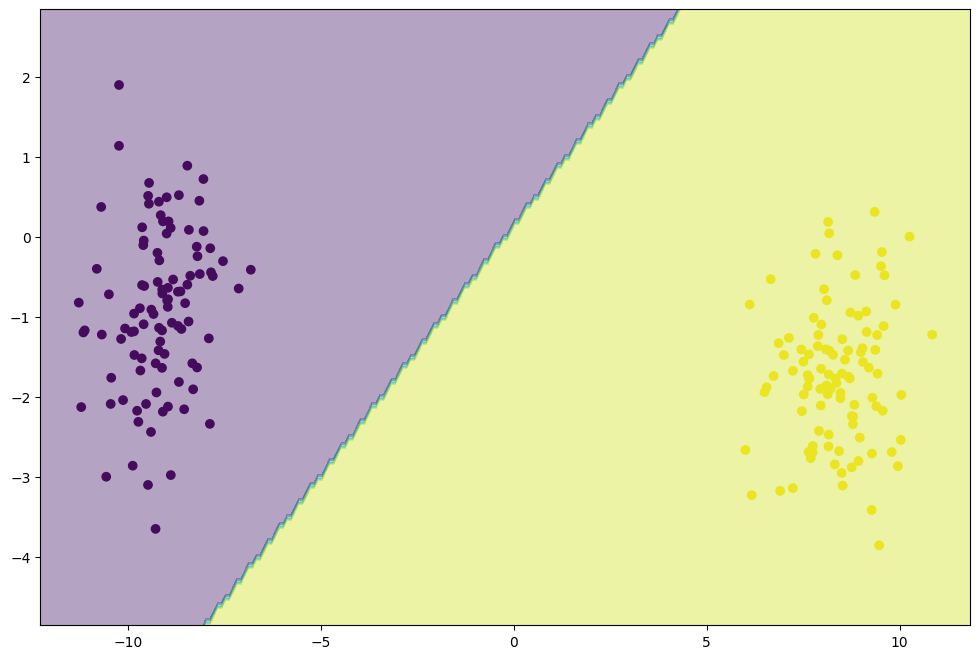

In [34]:
draw_boundary(perc, inputs, labels)

## Vícevrstvý perceptron

Jednoduchý perceptron už umíme, tak si nyní s jeho pomocí zkusíme napsat vícevrstevný perceptron, neboli celou (plně propojenou) neuronovou síť. V inicializační části nastavíme velikosti vrstev a poté matice vah mezi jednotlivými vrstvami jakožto náhodné hodnoty. Dále bude třeba umět predikovat výstupní hodnotu sítě pro daný vstup. Nakonec bude potřeba funkce trénování, která pro daný vstup spočítá výstup sítě a následně updatuje váhy pomocí backpropagace.

In [21]:
def sigmoid(x):
    return 1 / (1 + np.exp(x))


class MultiLayerPerceptron:
    def __init__(self, layer_sizes, training_iterations, alpha=0.1):
        self.layer_sizes = layer_sizes
        self.layers = []
        self.training_iterations = training_iterations
        self.alpha = alpha
        
        for (input_layer_size, output_layer_size) in zip(self.layer_sizes, self.layer_sizes[1:]):
           self.layers.append(np.random.normal(size=(input_layer_size + 1, output_layer_size)))
           
           
    def _add_ones(self, x):
        """ Add a column of ones for bias (the first row in the weight matrix represents the biases) """
        ones = np.ones(shape=(x.shape[0], 1))
        return np.concatenate([ones, x], axis=1)
    
    
    def predict(self, X):
        activations = np.array(X)
        try:
            for layer in self.layers:
                extended_activations = self._add_ones(activations)
                activations = sigmoid(np.dot(extended_activations, layer))
                
        except Exception as e:
            print("Activations:", activations)
            raise e

        return activations
    
    
    def fit(self, inputs, labels):
        pass
        # We need to compute the NN's output and then perform the backpropagation
        # Try to do so yourself

In [8]:
mlp = MultiLayerPerceptron([3,5,2])
# Predicting in batch
mlp.predict(np.array([[1,2,3], [1,2,7]]))

array([[0.16141959, 0.01639364],
       [0.15252632, 0.01301282]])

## Úkol na cvičení

Zkuste si dopsat funkci `fit` u vícevrstevného perceptronu a natrénovat ho na datasetu *winequality-white.csv* z UCI machine learning repository. Cílem u tohoto datasetu je predikovat kvalitu vína na základě 12 změřených fyzikálních a chemických vlastností. Kvalita se hodnotí na stupnici 0-10. 

In [3]:
data = pd.read_csv("winequality-white.csv", delimiter=';')
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [4]:
counter=collections.Counter(data["quality"])
print(counter)

Counter({6: 2198, 5: 1457, 7: 880, 8: 175, 4: 163, 3: 20, 9: 5})


Když se ale reálně podíváme na rozložení výsledných hodnot kvality vín v datasetu, tak vidíme, že většina výstupů je mezi 5 a 7. Proto si zjednoduššíme práci a dataset si upravíme tak, aby predikoval jen 3 výstupní kategorie s hodnotami 5 až 7 tak, že 3 a 4 sloučíme s 5 a zároveň 9 a 8 sloučíme se 7.

In [5]:
data["quality"].replace({3: 5, 4: 5, 8: 7, 9: 7}, inplace=True)
counter=collections.Counter(data["quality"])
print(counter)

Counter({6: 2198, 5: 1640, 7: 1060})


Na tomto upraveném datasetu si nyní zkusíme pustit vícevrstevný perceptron. Vidíme, že výsledky jsou nám k ničemu, protože nemáme naprogramovanou funkci `fit`. Zkuste si ji doprogramovat.

(Předpokládejte loss funkci ve tvaru *L = y_1 + ... y_(i-1) + (1 - y_i) + y_(i+1) + ... y_n*, kde *y* je výstupní vektor sítě (tedy to, co mi síť na konci vyplivne), máme *n* tříd (takže *y* má délku *n*) a *i*-tá složka odpovídá labelu, tedy třídě, kterou jsme chtěli predikovat. To odpovídá tomu, že chceme dostat na *i*-té pozici 1, zatímco všude jinde 0. Není to optimální, běžně bychom pro účely klasifikace do více tříd využili na konci funkci softmax a jako loss funkci tzv. "categorical crossentropy", ale tím se teď nebudeme zatěžovat a budeme pracovat s našimi sigmoidy a s naší ad hoc loss funkcí.)

In [23]:
labels = data["quality"].values
inputs = data.drop(columns="quality").values

inputs.shape

(4898, 11)

In [28]:
k = 10 
mlp = MultiLayerPerceptron([inputs.shape[1], k, len(np.unique(labels))])
mlp.fit(inputs, labels)
mlp.predict(inputs)

D:\Temp\ipykernel_11188\4124327227.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(x))


array([[0.39014879, 0.61645772, 0.62774355],
       [0.23856305, 0.49539383, 0.63934849],
       [0.23240468, 0.53650125, 0.7206041 ],
       ...,
       [0.21134433, 0.46878519, 0.64246403],
       [0.20065405, 0.45723837, 0.64292332],
       [0.19937295, 0.45644003, 0.64410089]])

## Knihovny tensorflow, keras, scikit-learn

Nejprve se seznámíme s pár základními knihovnami, které budeme používat pro snažší vytváření neuronových sítí a práci s nimi. Knihovna tensorflow je symbolická matematická knihovna, která slouží pro dataflow, tedy obsahuje grafové moduly a operace, nad kterými se následně dají implementovat různé algoritmy strojového učení. Nad ní běží knihovna keras, která je navržena pro snadné experimentování s hlubokými neuronovými sítěmi. Knihovna scikit-learn zase obsahuje všechny možné běžné algoritmy strojového učení.

Všechny tyto knihovny byly navrženy, aby uživateli zjednodušily práci se zpracováním dat a následné vytváření predikčních a jiných modelů, ať už pomocí neurovnových sítí nebo jiných algoritmů strojového učení.

Zkusíme si tedy s pomocí těchto knihoven naimplementovat tu samou jednoduchou neuronovou sít, jakou jsme si ručně napsali výše. Budeme si potřebovat vyrobit data, potom definovat síť a nakonec ji natrénovat na trénovacích datech a nechat ji predikovat a změřit svou chybu na testovacích datech.

Nejprve si vytvoříme náhodná dvojrozměrná data klasifikovatelná do n tříd, abychom si je mohli i hezky vizualizovat v grafu. K tomu bude potřeba si upravit funkci pro vizualizaci, protože vícetřídová klasifikace nám vrací výstup jakožto pole, kde pro danou jednu vybranou třídu (ideálně) bude na jejím indexu 1 a všude jinde budou 0. Tomuto výstupu se tak říká one-hot-encoding.

In [13]:
def draw_boundary_multiclass(model, inputs, labels):
    x_min = inputs[:, 0].min() - 1
    x_max = inputs[:, 0].max() + 1
    y_min = inputs[:, 1].min() - 1 
    y_max = inputs[:, 1].max() + 1

    # Create rectangular grid with the above computed dimensions
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    
    # Drawing of the decision boundary - each point gets a color accordingly
    predicted = model.predict(np.c_[xx.ravel(), yy.ravel()])
    
    # Extracting the predicted class number from the one-hot-encoding
    predicted = np.argmax(predicted, axis=1)
    
    predicted = predicted.reshape(xx.shape)
    
    plt.figure(figsize=(12,8))
    plt.scatter(inputs[:,0], inputs[:,1], c=labels)
    plt.contourf(xx, yy, predicted, alpha=0.4)
    plt.show()
    

Když máme upravenou funkci pro vizualizaci, vygenerujeme si náhodná data, vytvoříme model a podíváme se, jak byl model úspěšný, tedy jak dobře se natrénoval na trénovacích datech a jak umí predikovat data testovací.

In [14]:
# First let us prepare the data and split them to train and test sets
num_of_classes = 3
x, y = datasets.make_blobs(n_samples=300, centers=num_of_classes)

x_train, x_test = x[:250], x[250:]
y_train, y_test = y[:250], y[250:]


In [15]:
# Define the network architecture
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(5, activation=tf.nn.sigmoid)) # Inner layer with 5 neurons
model.add(tf.keras.layers.Dense(num_of_classes, activation=tf.nn.softmax)) # Output layer

# Set the optimization process hyperparameters
model.compile(optimizer="sgd", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Train the model on the training data
model.fit(x_train, y_train, epochs=200, verbose=1)
pass

Epoch 1/200
8/8 [==============================] - 2s 7ms/step - loss: 1.1767 - accuracy: 0.3360
Epoch 2/200
8/8 [==============================] - 0s 5ms/step - loss: 1.1548 - accuracy: 0.3360
Epoch 3/200
8/8 [==============================] - 0s 8ms/step - loss: 1.1370 - accuracy: 0.3360
Epoch 4/200
8/8 [==============================] - 0s 3ms/step - loss: 1.1216 - accuracy: 0.3360
Epoch 5/200
8/8 [==============================] - 0s 7ms/step - loss: 1.1080 - accuracy: 0.3360
Epoch 6/200
8/8 [==============================] - 0s 3ms/step - loss: 1.0956 - accuracy: 0.3360
Epoch 7/200
8/8 [==============================] - 0s 4ms/step - loss: 1.0844 - accuracy: 0.3360
Epoch 8/200
8/8 [==============================] - 0s 2ms/step - loss: 1.0737 - accuracy: 0.3360
Epoch 9/200
8/8 [==============================] - 0s 2ms/step - loss: 1.0636 - accuracy: 0.3360
Epoch 10/200
8/8 [==============================] - 0s 2ms/step - loss: 1.0541 - accuracy: 0.3360
Epoch 11/200
8/8 [===========

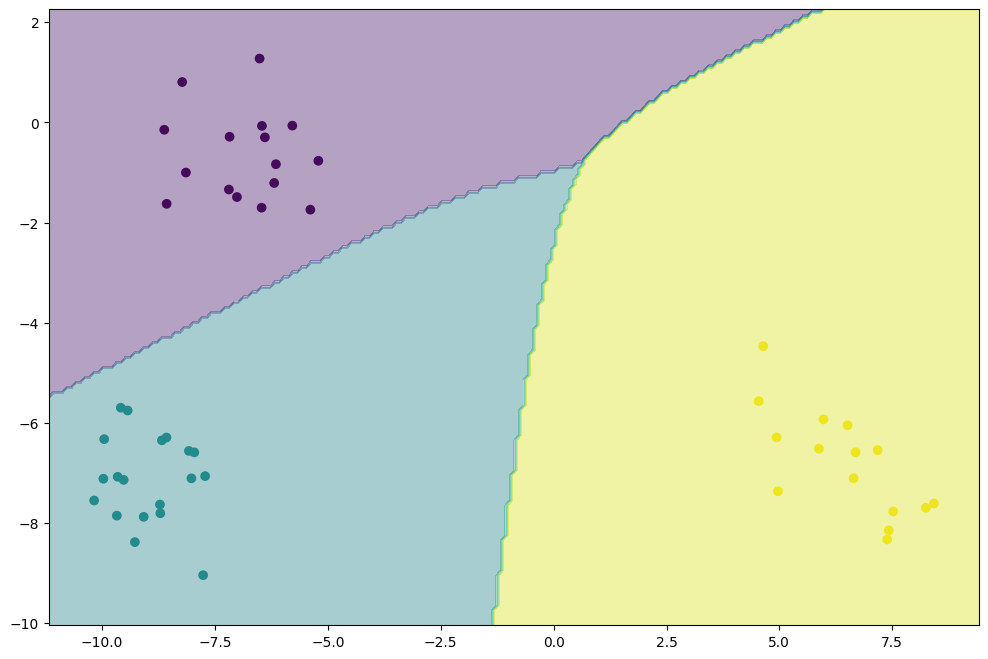

In [16]:
# We make and plot predictions on the test data
draw_boundary_multiclass(model, x_test, y_test)

Ještě si zkusíme pustit neuronovou síť z tensorflow na nějakém reálném datasetu. Nejjednodušší volbou je dataset o víně, který jsme si už popsali výše. Aby však síť mohla správně klasifikovat labely, je potřeba je posunout z množiny {5, 6, 7} do množiny {0, 1, 2}. Následně ještě provedeme normalizaci ostatních hodnot tak, že všechny sloupečky budou mít hodnoty v intervalu \[0, 1\]. Normalizace se dělá proto, aby se nestalo, že některý sloupeček s hodně vysokými hodnotami bude mít příliš velký vliv na výsledný predikovaný label. 

In [23]:
# Randomly shuffle the data
data = shuffle(data)

# Shift the labels
data["quality"].replace({5: 0, 6: 1, 7: 2}, inplace=True)
labels = data["quality"].values

# Data normalization
values = data[data.columns.difference(["quality"])].values
min_max_scaler = preprocessing.MinMaxScaler()
data_scaled = min_max_scaler.fit_transform(values)

# Split the data to train and test sets
x, y = data_scaled, labels
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [28]:
# Define the network architecture
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(5, activation=tf.nn.sigmoid))
model.add(tf.keras.layers.Dense(3, activation=tf.nn.softmax))

# Set the optimization process hyperparameters
model.compile(optimizer="sgd", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Train the model on the training data
model.fit(x_train, y_train, epochs=200, verbose=1)
pass

Epoch 1/200


115/115 [==============================] - 1s 2ms/step - loss: 1.1802 - accuracy: 0.3507
Epoch 2/200
115/115 [==============================] - 0s 1ms/step - loss: 1.0773 - accuracy: 0.3616
Epoch 3/200
115/115 [==============================] - 0s 1ms/step - loss: 1.0553 - accuracy: 0.4511
Epoch 4/200
115/115 [==============================] - 0s 1ms/step - loss: 1.0506 - accuracy: 0.4511
Epoch 5/200
115/115 [==============================] - 0s 1ms/step - loss: 1.0493 - accuracy: 0.4511
Epoch 6/200
115/115 [==============================] - 0s 1ms/step - loss: 1.0487 - accuracy: 0.4511
Epoch 7/200
115/115 [==============================] - 0s 1ms/step - loss: 1.0482 - accuracy: 0.4511
Epoch 8/200
115/115 [==============================] - 0s 1ms/step - loss: 1.0479 - accuracy: 0.4511
Epoch 9/200
115/115 [==============================] - 0s 2ms/step - loss: 1.0475 - accuracy: 0.4511
Epoch 10/200
115/115 [==============================] - 0s 2ms/step - loss: 1.0470 - accuracy: 0.4511
E

Zkusíme si predikovat výstup na testovacích datech a spočítat přesnost. 

In [29]:
# Prediction on the test data
predictions = model.predict(x_test)
predicted_classes = np.argmax(predictions, axis=-1)
model_accuracy = accuracy_score(predicted_classes, y_test)
print(model_accuracy)

0.5330612244897959


Na závěr se podíváme na matici konfuze, která nám říká, která třída byla kolikrát dobře nebo zle predikovaná.

[[220 176   4]
 [147 372  22]
 [ 31 192  61]]


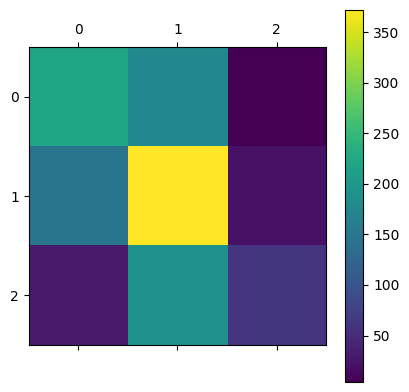

[[400   0   0]
 [  0 541   0]
 [  0   0 284]]


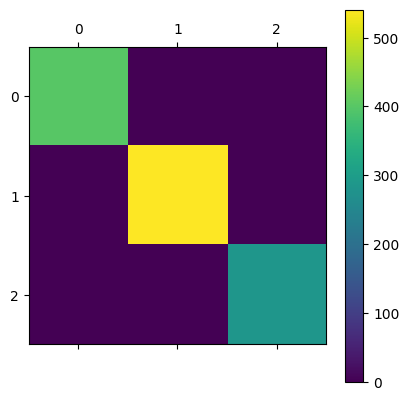

In [30]:
confusion_matrix = metrics.confusion_matrix(y_test, predicted_classes)
print(confusion_matrix)

pl.matshow(confusion_matrix)
pl.colorbar()
pl.show()

confusion_matrix = metrics.confusion_matrix(y_test, y_test)
print(confusion_matrix)

pl.matshow(confusion_matrix)
pl.colorbar()
pl.show()